# Unidad 4 · VRPTW: rutear técnicos, y por qué una infactibilidad hay que explicarla

**Planta:** Conservas del Itata S.A. — servicio técnico de cámaras de frío
**Datos:** `DatosClases/4_Secuenciamiento/itata_tecnicos_visitas.csv`
(depósito + 8 clientes mayoristas) y `itata_tecnicos_distancias.csv`
**Solver:** Gurobi

---

## Qué se decide aquí

Itata mantiene las cámaras de frío de sus ocho clientes mayoristas. Los
técnicos salen de planta en la mañana, visitan a los que les toque, y vuelven.
Cada cliente tiene una **ventana horaria** —el casino no deja entrar a un
técnico en pleno almuerzo, el hotel solo abre bodega en la mañana— y la
jornada es de 11 h.

Esto es secuenciamiento aunque no lo parezca, y conviene ver por qué antes de
escribir nada. El recurso escaso es el técnico, las tareas son las visitas, y
el "cambio de preparación" entre dos tareas consecutivas es el **tiempo de
viaje**. Es exactamente la estructura del cuaderno 02, `1|s_ij|Cmax`, con dos
diferencias: el `s_ij` sale de la geografía en vez de una tabla de limpieza, y
hay ventanas que respetar. La tercera diferencia —que puede haber más de un
técnico— es la que lo convierte en un problema de ruteo y no de una máquina.

## Las dos cosas que este cuaderno quiere dejar clavadas

**Una infactibilidad reportada por el solver no explica nada.** Con **un solo
técnico** este problema no tiene solución, y `INFEASIBLE` es una respuesta
inútil para ir a hablar con el cliente. Hay que poder decir *cuál* par de
exigencias se contradice, y eso se averigua aparte del solver. Es el mismo
punto que el ciclo positivo del cuaderno 06: el diagnóstico se construye,
no se le pide al solver.

**En un VRPTW se puede ESPERAR.** El técnico puede llegar antes de que la
ventana abra y aguardar en la puerta. Un verificador que exija que el servicio
empiece exactamente en el instante de llegada rechaza soluciones perfectamente
válidas. Es un error real y cuesta encontrarlo, porque el modelo sigue
entregando el número correcto: lo que falla es la comprobación.

## Cifras de referencia

| flota | resultado |
|---|---|
| K = 1 técnico | **INFACTIBLE** — y no por falta de horas |
| K = 2 técnicos | **5,594 h** de viaje |
| K = 3 técnicos | **5,159 h** de viaje |

Que K = 3 viaje **menos** que K = 2 no es un error de tipeo, y explicar por
qué pasa es parte del cuaderno.

In [1]:
import sys
import time
import itertools
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

vis = pd.read_csv(datos("4_Secuenciamiento", "itata_tecnicos_visitas.csv"))
dis = pd.read_csv(datos("4_Secuenciamiento", "itata_tecnicos_distancias.csv"))

NODOS = list(vis.nodo)
DEPOSITO = NODOS[0]
CLIENTES = NODOS[1:]
nombre = dict(zip(vis.nodo, vis.nombre))
xy = {r.nodo: (float(r.x_km), float(r.y_km)) for _, r in vis.iterrows()}
serv = {r.nodo: float(r.servicio_h) for _, r in vis.iterrows()}
e = {r.nodo: float(r.ventana_inicio_h) for _, r in vis.iterrows()}
l = {r.nodo: float(r.ventana_fin_h) for _, r in vis.iterrows()}
tv = {(r.desde, r.hacia): float(r.tiempo_viaje_h) for _, r in dis.iterrows()}
km = {(r.desde, r.hacia): float(r.distancia_km) for _, r in dis.iterrows()}

JORNADA = 11.0

print(f"1 depósito + {len(CLIENTES)} clientes · jornada {JORNADA:.0f} h\n")
print(vis.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
print(f"\nServicio total comprometido: {sum(serv[c] for c in CLIENTES):.1f} h")
print(f"Ventana más angosta: " + ", ".join(
    f"{c} [{e[c]:.1f}, {l[c]:.1f}] ({l[c]-e[c]:.1f} h)"
    for c in sorted(CLIENTES, key=lambda z: l[z] - e[z])[:3]))

1 depósito + 8 clientes · jornada 11 h

nodo                  nombre   x_km   y_km  servicio_h  ventana_inicio_h  ventana_fin_h
   D Planta Itata (deposito)   0.00   0.00        0.00              0.00          11.00
  C1       Mayorista Chillan  18.00   7.00        1.60              1.00           4.00
  C2      Frigorifico Bulnes  -9.00  14.00        2.10              2.00           6.00
  C3           Casino Termas  25.00  -6.00        1.30              0.50           2.60
  C4     Supermercado Yungay -14.00  -5.00        1.80              3.50           7.00
  C5   Distribuidora Coelemu   6.00  22.00        1.50              4.00           8.00
  C6          Hotel Quirihue -20.00  11.00        1.10              1.00           3.20
  C7            Central Tome  12.00 -18.00        2.00              5.00           8.50
  C8            Bodega Penco   3.00 -12.00        1.40              0.50           4.50

Servicio total comprometido: 12.8 h
Ventana más angosta: C3 [0.5, 2.6] (2.1 h),

## 1. La cuenta de servilleta que no alcanza

Lo primero que hace cualquiera al mirar estos datos es sumar: 12,8 h de
servicio contra una jornada de 11 h por técnico. De ahí sale que "hacen falta
al menos dos técnicos", y es cierto, pero es una cota **floja** y sobre todo
es una cota sobre la cosa equivocada.

El problema de un técnico solo no va a ser la suma de horas. Va a ser la
**geometría contra el reloj**, y esa cuenta no se hace sumando.

In [2]:
servicio_total = sum(serv[c] for c in CLIENTES)
print(f"servicio total                  {servicio_total:6.2f} h")
print(f"jornada de un técnico           {JORNADA:6.2f} h")
print(f"cota por carga: al menos        {int(np.ceil(servicio_total / JORNADA))} técnicos "
      f"(y eso ignorando por completo los viajes)")
print()
print("Ventanas ordenadas por hora de cierre:\n")
for c in sorted(CLIENTES, key=lambda z: l[z]):
    print(f"  {c}  {nombre[c]:26s}  [{e[c]:4.1f} , {l[c]:4.1f}]   "
          f"servicio {serv[c]:.1f} h   ida desde D {tv[(DEPOSITO, c)]:.3f} h")

servicio total                   12.80 h
jornada de un técnico            11.00 h
cota por carga: al menos        2 técnicos (y eso ignorando por completo los viajes)

Ventanas ordenadas por hora de cierre:

  C3  Casino Termas               [ 0.5 ,  2.6]   servicio 1.3 h   ida desde D 0.677 h
  C6  Hotel Quirihue              [ 1.0 ,  3.2]   servicio 1.1 h   ida desde D 0.601 h
  C1  Mayorista Chillan           [ 1.0 ,  4.0]   servicio 1.6 h   ida desde D 0.508 h
  C8  Bodega Penco                [ 0.5 ,  4.5]   servicio 1.4 h   ida desde D 0.326 h
  C2  Frigorifico Bulnes          [ 2.0 ,  6.0]   servicio 2.1 h   ida desde D 0.438 h
  C4  Supermercado Yungay         [ 3.5 ,  7.0]   servicio 1.8 h   ida desde D 0.391 h
  C5  Distribuidora Coelemu       [ 4.0 ,  8.0]   servicio 1.5 h   ida desde D 0.600 h
  C7  Central Tome                [ 5.0 ,  8.5]   servicio 2.0 h   ida desde D 0.569 h


## 2. Reconstruir el calendario de una ruta: se puede ESPERAR

Antes de cualquier modelo hace falta una función que, dada una ruta, diga
exactamente qué hace el técnico y a qué hora. Es la misma idea que
`evaluar_permutacion` en el cuaderno 04: el modelo elige el orden, pero el
calendario se reconstruye simulando hacia adelante.

Y acá está la trampa. La recursión es

$$\text{llegada}(j) = \text{inicio}(i) + \text{serv}_i + t_{ij}, \qquad
  \boxed{\text{inicio}(j) = \max\big(\text{llegada}(j),\; e_j\big)}$$

Ese `max` es todo el asunto. Si el técnico llega a las 0,33 h a un cliente
cuya ventana abre a las 0,50 h, **espera 10 minutos y atiende**. La visita es
perfectamente válida. La restricción de ventana es

$$e_j \le \text{inicio}(j) \le l_j$$

y lo que hay que verificar contra `l_j` es la **llegada** (si llega después
del cierre, no hay nada que hacer), mientras que contra `e_j` no hay nada que
verificar: se espera y punto.

El error que este cuaderno quiere evitar —y que ya se cometió— es escribir el
verificador con `inicio(j) == llegada(j)`. Esa igualdad rechaza toda solución
en que haya una espera, que son la mayoría de las soluciones buenas de un
VRPTW, y lo peor es que no falla ruidosamente: informa que el óptimo del
solver "no es factible" y manda a buscar un error que está en el verificador.

In [3]:
def simular_ruta(ruta):
    """Calendario de una ruta [D, c1, ..., ck, D]. Devuelve filas y veredicto.

    Simula hacia adelante y PERMITE ESPERAR: el servicio empieza en
    max(llegada, apertura de la ventana).
    """
    filas, reloj, factible, motivo = [], 0.0, True, ""
    for i, j in zip(ruta, ruta[1:]):
        viaje = tv[(i, j)]
        llegada = reloj + viaje
        if j == DEPOSITO:
            filas.append({"nodo": j, "viaje_h": viaje, "llegada": llegada,
                          "espera_h": 0.0, "inicio": llegada, "fin": llegada})
            reloj = llegada
            if llegada > JORNADA + 1e-9:
                factible, motivo = False, (
                    f"vuelve al depósito en {llegada:.4f} h y la jornada es "
                    f"{JORNADA:.1f} h")
            break
        if llegada > l[j] + 1e-9:
            factible, motivo = False, (
                f"llega a {j} en {llegada:.4f} h y su ventana cierra en {l[j]:.2f} h")
        inicio = max(llegada, e[j])          # <- se espera si se llega antes
        espera = inicio - llegada
        fin = inicio + serv[j]
        filas.append({"nodo": j, "viaje_h": viaje, "llegada": llegada,
                      "espera_h": espera, "inicio": inicio, "fin": fin})
        reloj = fin
    return pd.DataFrame(filas), factible, motivo


def factible_ruta(orden):
    """True si un técnico puede hacer esa secuencia de clientes en un turno."""
    _df, ok, _m = simular_ruta([DEPOSITO, *orden, DEPOSITO])
    return ok


demo = [DEPOSITO, "C8", "C6", "C2", "C4", DEPOSITO]
df_demo, ok_demo, _ = simular_ruta(demo)
print(f"Ejemplo: {' -> '.join(demo)}   factible = {ok_demo}\n")
print(df_demo.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))
print(f"\nEspera total en esta ruta: {df_demo.espera_h.sum():.4f} h. Un")
print("verificador que exigiera inicio == llegada la habría rechazado.")

Ejemplo: D -> C8 -> C6 -> C2 -> C4 -> D   factible = True

nodo  viaje_h  llegada  espera_h  inicio    fin
  C8   0.3255   0.3255    0.1745  0.5000 1.9000
  C6   0.8560   2.7560    0.0000  2.7560 3.8560
  C2   0.3000   4.1560    0.0000  4.1560 6.2560
  C4   0.5170   6.7730    0.0000  6.7730 8.5730
   D   0.3912   8.9642    0.0000  8.9642 8.9642

Espera total en esta ruta: 0.1745 h. Un
verificador que exigiera inicio == llegada la habría rechazado.


## 3. K = 1: infactible, y saber por qué

Con ocho clientes hay `8! = 40 320` órdenes posibles para un técnico solo. Son
suficientemente pocos como para **enumerarlos todos** y contar cuántos
sobreviven a las ventanas y a la jornada.

Esto no es un método de solución —con 12 clientes ya serían 479 millones— pero
como **diagnóstico** es imbatible: un solver que dice `INFEASIBLE` afirma que
ninguno de los 40 320 funciona; la enumeración lo confirma **y** deja el
terreno preparado para averiguar qué exactamente lo impide.

In [4]:
t0 = time.perf_counter()
factibles = [o for o in itertools.permutations(CLIENTES) if factible_ruta(o)]
seg_enum = time.perf_counter() - t0
print(f"{len(list(itertools.permutations(CLIENTES))):,} órdenes evaluados en "
      f"{seg_enum:.1f} s")
print(f"  factibles con UN técnico: {len(factibles)}")
print("\nNinguno. Y con eso ya se sabe que el solver va a decir INFEASIBLE,")
print("pero todavía no se sabe NADA sobre por qué.")

40,320 órdenes evaluados en 6.4 s
  factibles con UN técnico: 0

Ninguno. Y con eso ya se sabe que el solver va a decir INFEASIBLE,
pero todavía no se sabe NADA sobre por qué.


### Aislar el par de restricciones que se contradice

La enumeración dice que no hay solución; no dice qué la impide. Para eso sirve
una **relajación**: se toman los clientes **de a dos** y se pregunta si un
técnico podría atender a esos dos y nada más. Si ni siquiera ese problema de
dos clientes tiene solución —ni en un orden ni en el otro—, entonces **ninguna
ruta** que contenga a ambos existe, porque agregar clientes solo puede empeorar
las cosas.

Es un argumento de relajación en toda regla, y da un certificado que se puede
leer en voz alta.

In [5]:
print("Pares que NO pueden estar en la misma ruta (relajación a dos clientes):\n")
pares_imposibles = []
for i, j in itertools.combinations(CLIENTES, 2):
    if not factible_ruta((i, j)) and not factible_ruta((j, i)):
        pares_imposibles.append((i, j))
        print(f"  {i} ({nombre[i]})  y  {j} ({nombre[j]})")
        for a, b in ((i, j), (j, i)):
            sale = max(tv[(DEPOSITO, a)], e[a]) + serv[a]
            llega = sale + tv[(a, b)]
            print(f"     D -> {a} -> {b} :  lo antes posible se llega a {b} a las "
                  f"{llega:.4f} h,\n"
                  f"        y su ventana cierra a las {l[b]:.2f} h  "
                  f"->  {llega - l[b]:+.4f} h")
        print()

if not pares_imposibles:
    print("  (ninguno)")

Pares que NO pueden estar en la misma ruta (relajación a dos clientes):

  C3 (Casino Termas)  y  C6 (Hotel Quirihue)
     D -> C3 -> C6 :  lo antes posible se llega a C6 a las 3.2425 h,
        y su ventana cierra a las 3.20 h  ->  +0.0425 h
     D -> C6 -> C3 :  lo antes posible se llega a C3 a las 3.3659 h,
        y su ventana cierra a las 2.60 h  ->  +0.7659 h



### El certificado, en una frase que se le puede decir al cliente

El par es **C3 (Casino Termas)** y **C6 (Hotel Quirihue)**, y la aritmética
cabe en dos líneas:

* C3 está a 25,7 km al **oriente** y cierra a las 2,6 h. C6 está a 22,8 km al
  **poniente** y cierra a las 3,2 h. Entre los dos hay 48,1 km, la distancia
  más larga de toda la red.
* Yendo primero a C3 —salir a las 0,68, atender 1,3 h, viajar 1,27 h— se llega
  a C6 a las **3,24 h**, y C6 cerró a las 3,20. Faltan **dos minutos y medio**.
* Yendo primero a C6 —que además obliga a esperar, porque abre a la 1,0 h— se
  llega a C3 a las **3,37 h**, y C3 cerró a las 2,60. Faltan 46 minutos.

Eso es lo que hay que llevar a la reunión, y es una afirmación **accionable**
de una forma que `INFEASIBLE` nunca va a ser: si el casino corriera su cierre
de las 2,6 a las 3,4 h, o si el hotel corriera el suyo de las 3,2 a las 3,25,
un técnico solo bastaría para ese par. La conversación comercial existe porque
existe el certificado.

Nótese además cuál es la holgura: **0,0425 h**. Dos minutos y medio de
diferencia son los que obligan a poner un segundo técnico en la calle todos
los días. Ese es el tipo de cosa que nadie descubre mirando un mapa.

## 4. El modelo VRPTW

**Variables.** Una binaria por arco, `x_ij = 1` si algún técnico viaja directo
de `i` a `j`, y una continua `a_i` por nodo con el instante de inicio del
servicio.

**Restricciones.**

$$\sum_{i \ne j} x_{ij} = 1, \quad \sum_{i \ne j} x_{ji} = 1 \qquad \forall j \in \text{clientes}$$

$$\sum_{j} x_{Dj} = \sum_{i} x_{iD} = K \qquad \text{salen y vuelven } K \text{ técnicos}$$

$$a_j \;\ge\; a_i + \text{serv}_i + t_{ij} - M_{ij}\,(1 - x_{ij}) \qquad \forall\, i,\; j \ne D$$

$$e_j \le a_j \le l_j$$

### Por qué no hace falta MTZ

La formulación de flujo por sí sola admite **subciclos**: un grupo de clientes
que se visitan entre sí sin pasar nunca por el depósito satisface todas las
ecuaciones de grado. La forma estándar de eliminarlos es agregar restricciones
MTZ o cortes de subciclo.

Acá no hace falta, y la razón es bonita: la restricción de tiempo ya lo hace
gratis. Recorriendo un subciclo `i → j → ... → i` y encadenando la desigualdad
se obtiene `a_i ≥ a_i + (tiempo del ciclo)`, con el tiempo del ciclo
estrictamente positivo. Imposible. **Las ventanas de tiempo eliminan los
subciclos por su cuenta**, y conviene saberlo porque el mismo modelo sin
ventanas sí necesitaría MTZ.

### El big-M, otra vez, y ahora sí ajustado arco por arco

El cuaderno 05 dejó la regla: el big-M se calcula a partir de lo que la
restricción tiene que desactivar. Cuando `x_ij = 0` hay que garantizar que

$$a_j \ge a_i + \text{serv}_i + t_{ij} - M_{ij}$$

se cumpla siempre. El peor caso es `a_i` en su máximo `l_i` y `a_j` en su
mínimo `e_j`, así que

$$M_{ij} = \max\big(0,\; l_i + \text{serv}_i + t_{ij} - e_j\big)$$

es válido y es el más chico que lo es. A diferencia del cuaderno 05, acá **sí**
se nota: cada arco tiene su propia `M`, las ventanas son angostas, y un único
`M` grueso tendría que ser el máximo de todas ellas.

Un caso vale la pena leerlo: `M_ij = 0` significa `l_i + serv_i + t_ij ≤ e_j`,
o sea que aun saliendo de `i` lo más tarde posible se llega a `j` antes de que
su ventana abra. La desigualdad se cumple sola y la restricción es
**redundante**. No dice que el arco sea imposible: dice que el tiempo nunca va
a ser el problema en ese arco.

### Los arcos que sí son imposibles

Ese es otro cálculo, y es puro preprocesamiento. Saliendo de `i` lo más
**temprano** posible se llega a `j` en `e_i + serv_i + t_ij`. Si eso ya pasa
de `l_j`, el arco `i → j` **no se puede usar nunca** y su binaria se puede
fijar en cero antes de resolver.

En esta instancia eso elimina un tercio largo de los arcos, y es exactamente
la clase de reducción que un modelo grande necesita y que ninguna biblioteca
va a hacer por uno.

In [6]:
arcos = [(i, j) for i in NODOS for j in NODOS if i != j]
M_arco = {(i, j): max(0.0, l[i] + serv[i] + tv[(i, j)] - e[j])
          for (i, j) in arcos if j != DEPOSITO}
imposibles = [(i, j) for (i, j) in M_arco
              if e[i] + serv[i] + tv[(i, j)] > l[j] + 1e-9]

vals = np.array(list(M_arco.values()))
print(f"{len(arcos)} arcos · {len(M_arco)} con restricción de tiempo\n")
print(f"big-M por arco:  mínimo {vals.min():.3f}   "
      f"mediana {np.median(vals):.3f}   máximo {vals.max():.3f}")
print(f"  un big-M único y grueso tendría que valer {vals.max():.3f} para todos")
print(f"  arcos con M = 0 (restricción redundante): {int((vals <= 1e-9).sum())}")
print(f"\narcos IMPOSIBLES por ventana (e_i + serv_i + t_ij > l_j): "
      f"{len(imposibles)} de {len(M_arco)} "
      f"({100*len(imposibles)/len(M_arco):.0f} %)")
print("  " + ", ".join(f"{i}→{j}" for i, j in imposibles[:11]))
print("  " + ", ".join(f"{i}→{j}" for i, j in imposibles[11:]))
origen_c7 = [j for (i, j) in imposibles if i == "C7"]
print(f"\nC7 (Central Tomé, ventana 5,0–8,5) no puede preceder a NINGUNO de los "
      f"otros {len(origen_c7)} clientes:")
print("quien la visite tiene que volver derecho a planta. No es una decisión")
print("del modelo, es aritmética de ventanas, y se sabe antes de resolver.")

72 arcos · 64 con restricción de tiempo

big-M por arco:  mínimo 0.000   mediana 5.747   máximo 11.177
  un big-M único y grueso tendría que valer 11.177 para todos
  arcos con M = 0 (restricción redundante): 1

arcos IMPOSIBLES por ventana (e_i + serv_i + t_ij > l_j): 22 de 64 (34 %)
  C1→C3, C1→C6, C2→C1, C2→C3, C2→C6, C2→C8, C4→C1, C4→C3, C4→C6, C4→C8, C5→C1
  C5→C3, C5→C6, C5→C8, C6→C3, C7→C1, C7→C2, C7→C3, C7→C4, C7→C5, C7→C6, C7→C8

C7 (Central Tomé, ventana 5,0–8,5) no puede preceder a NINGUNO de los otros 7 clientes:
quien la visite tiene que volver derecho a planta. No es una decisión
del modelo, es aritmética de ventanas, y se sabe antes de resolver.


In [7]:
def resolver_vrptw(K, objetivo="tiempo", podar=False, tiempo_limite=120.0):
    m = gp.Model(f"VRPTW-K{K}")
    m.Params.OutputFlag = 0
    m.Params.TimeLimit = tiempo_limite
    m.Params.MIPGap = 1e-9
    m.Params.Seed = 0

    x = m.addVars(arcos, vtype=GRB.BINARY, name="x")
    a = m.addVars(NODOS, lb=0.0, name="a")
    for n in NODOS:                       # las ventanas, como cotas de la variable
        a[n].LB, a[n].UB = e[n], l[n]
    if podar:                             # preprocesamiento: arcos imposibles
        for (i, j) in imposibles:
            x[i, j].UB = 0.0

    for j in CLIENTES:
        m.addConstr(gp.quicksum(x[i, j] for i in NODOS if i != j) == 1,
                    name=f"entra[{j}]")
        m.addConstr(gp.quicksum(x[j, i] for i in NODOS if i != j) == 1,
                    name=f"sale[{j}]")
    m.addConstr(gp.quicksum(x[DEPOSITO, j] for j in CLIENTES) == K, name="salidas")
    m.addConstr(gp.quicksum(x[i, DEPOSITO] for i in CLIENTES) == K, name="retornos")

    for (i, j) in arcos:
        if j == DEPOSITO:
            continue                      # el retorno lo cubre la jornada
        m.addConstr(a[j] >= a[i] + serv[i] + tv[(i, j)]
                    - M_arco[i, j] * (1 - x[i, j]), name=f"tiempo[{i},{j}]")

    for i in CLIENTES:                    # volver antes del cierre de jornada
        m.addConstr(a[i] + serv[i] + tv[(i, DEPOSITO)]
                    <= JORNADA + (1 - x[i, DEPOSITO]) * 1e4, name=f"jornada[{i}]")

    costo = tv if objetivo == "tiempo" else km
    m.setObjective(gp.quicksum(costo[(i, j)] * x[i, j] for (i, j) in arcos),
                   GRB.MINIMIZE)

    t0 = time.perf_counter()
    m.optimize()
    seg = time.perf_counter() - t0
    estado = {GRB.OPTIMAL: "OPTIMAL", GRB.TIME_LIMIT: "TIME_LIMIT",
              GRB.INFEASIBLE: "INFEASIBLE"}.get(m.Status, f"STATUS_{m.Status}")
    out = {"K": K, "estado": estado, "vars": m.NumVars, "binarias": m.NumBinVars,
           "restr": m.NumConstrs, "seg": seg, "nodos": int(m.NodeCount),
           "objetivo": None, "gap_%": None, "rutas": []}
    if m.SolCount == 0:
        return out
    out["objetivo"] = m.ObjVal
    out["gap_%"] = 100 * m.MIPGap
    # Reconstruccion de las rutas siguiendo los arcos activos.
    sucesor = {i: j for (i, j) in arcos if x[i, j].X > 0.5 and i != DEPOSITO}
    for primero in sorted(j for j in CLIENTES if x[DEPOSITO, j].X > 0.5):
        r, actual = [DEPOSITO], primero
        while actual != DEPOSITO:
            r.append(actual)
            actual = sucesor.get(actual, DEPOSITO)
        r.append(DEPOSITO)
        out["rutas"].append(r)
    out["km"] = sum(km[(i, j)] for (i, j) in arcos if x[i, j].X > 0.5)
    return out


SOL = {K: resolver_vrptw(K) for K in (1, 2, 3)}

print(f"{'K':>3s} {'estado':>11s} {'viaje h':>9s} {'km':>8s} {'gap %':>7s} "
      f"{'vars':>6s} {'binarias':>9s} {'restr':>7s} {'nodos':>7s} {'seg':>8s}")
for K in (1, 2, 3):
    s = SOL[K]
    obj = f"{s['objetivo']:9.3f}" if s["objetivo"] is not None else "        —"
    kms = f"{s['km']:8.2f}" if s["objetivo"] is not None else "       —"
    gap = f"{s['gap_%']:7.4f}" if s["gap_%"] is not None else "      —"
    print(f"{K:3d} {s['estado']:>11s} {obj} {kms} {gap} {s['vars']:6d} "
          f"{s['binarias']:9d} {s['restr']:7d} {s['nodos']:7d} {s['seg']:8.3f}")

print("\nEl solver confirma lo que la enumeración ya sabía para K = 1. La")
print("diferencia es que la enumeración vino con un certificado y el solver no.")

print("\nY el preprocesamiento de arcos, comprobado: fijar en cero las binarias")
print("de los arcos imposibles no debe cambiar el óptimo, solo el tamaño.\n")
for K in (2, 3):
    podado = resolver_vrptw(K, podar=True)
    print(f"  K = {K}:  sin podar {SOL[K]['objetivo']:.4f} h  ·  "
          f"podado {podado['objetivo']:.4f} h  ·  "
          f"{'IGUAL' if abs(podado['objetivo'] - SOL[K]['objetivo']) < 1e-9 else 'DIFIERE'}")
    assert abs(podado["objetivo"] - SOL[K]["objetivo"]) < 1e-9, \
        "podar arcos imposibles no puede cambiar el óptimo"

Restricted license - for non-production use only - expires 2027-11-29


  K      estado   viaje h       km   gap %   vars  binarias   restr   nodos      seg
  1  INFEASIBLE         —        —       —     81        72      90       0    0.001
  2     OPTIMAL     5.594   212.58  0.0000     81        72      90       1    0.016
  3     OPTIMAL     5.159   196.05  0.0000     81        72      90       1    0.003

El solver confirma lo que la enumeración ya sabía para K = 1. La
diferencia es que la enumeración vino con un certificado y el solver no.

Y el preprocesamiento de arcos, comprobado: fijar en cero las binarias
de los arcos imposibles no debe cambiar el óptimo, solo el tamaño.

  K = 2:  sin podar 5.5940 h  ·  podado 5.5940 h  ·  IGUAL
  K = 3:  sin podar 5.1590 h  ·  podado 5.1590 h  ·  IGUAL


## 5. Los calendarios, reconstruidos y con las esperas a la vista

El modelo tiene una variable `a_i` por cliente, y sería cómodo leer de ahí los
instantes de servicio. **No hay que hacerlo.** El modelo solo *acota* esas
variables —`a_j ≥ ...` y la ventana—, y como el objetivo no las castiga, el
solver puede dejarlas en cualquier punto de su rango sin costo. `a_i.X` es un
valor factible, no el instante en que el técnico va a llegar.

El calendario se reconstruye **simulando la ruta hacia adelante**, que es lo
que el técnico efectivamente va a hacer, y es lo único que el verificador
puede comprobar.

In [8]:
def informe_rutas(K):
    s = SOL[K]
    print(f"=== K = {K}  ·  {s['objetivo']:.3f} h de viaje  ·  {s['km']:.2f} km\n")
    total_espera = 0.0
    for n, ruta in enumerate(s["rutas"], start=1):
        df, ok, motivo = simular_ruta(ruta)
        total_espera += float(df.espera_h.sum())
        retorno = float(df.fin.iloc[-1])
        print(f"  Técnico T{n}:  {' -> '.join(ruta)}")
        print(f"     viaje {sum(tv[(i, j)] for i, j in zip(ruta, ruta[1:])):.3f} h"
              f"  ·  espera {df.espera_h.sum():.3f} h"
              f"  ·  vuelve a las {retorno:.3f} h de {JORNADA:.0f}"
              f"  ·  {'FACTIBLE' if ok else 'INFACTIBLE: ' + motivo}")
        vista = df.copy()
        vista["ventana"] = [f"[{e[x]:.1f}, {l[x]:.1f}]" if x != DEPOSITO else ""
                            for x in vista.nodo]
        print(vista[["nodo", "viaje_h", "llegada", "espera_h", "inicio", "fin",
                     "ventana"]].to_string(index=False,
                                           float_format=lambda v: f"{v:,.3f}"))
        print()
    print(f"  Espera total de la flota: {total_espera:.3f} h\n")
    return total_espera


espera_K2 = informe_rutas(2)
espera_K3 = informe_rutas(3)

=== K = 2  ·  5.594 h de viaje  ·  212.58 km

  Técnico T1:  D -> C3 -> C1 -> C5 -> C7 -> D
     viaje 3.204 h  ·  espera 0.000 h  ·  vuelve a las 9.604 h de 11  ·  FACTIBLE
nodo  viaje_h  llegada  espera_h  inicio   fin    ventana
  C3    0.677    0.677     0.000   0.677 1.977 [0.5, 2.6]
  C1    0.389    2.365     0.000   2.365 3.965 [1.0, 4.0]
  C5    0.505    4.471     0.000   4.471 5.971 [4.0, 8.0]
  C7    1.064    7.035     0.000   7.035 9.035 [5.0, 8.5]
   D    0.569    9.604     0.000   9.604 9.604           

  Técnico T2:  D -> C8 -> C6 -> C2 -> C4 -> D
     viaje 2.390 h  ·  espera 0.174 h  ·  vuelve a las 8.964 h de 11  ·  FACTIBLE
nodo  viaje_h  llegada  espera_h  inicio   fin    ventana
  C8    0.326    0.326     0.174   0.500 1.900 [0.5, 4.5]
  C6    0.856    2.756     0.000   2.756 3.856 [1.0, 3.2]
  C2    0.300    4.156     0.000   4.156 6.256 [2.0, 6.0]
  C4    0.517    6.773     0.000   6.773 8.573 [3.5, 7.0]
   D    0.391    8.964     0.000   8.964 8.964           



### La espera no es tiempo perdido del modelo: es parte de la solución

En el plan de dos técnicos hay espera, y es **obligatoria**: el técnico llega
a Bodega Penco antes de que abran y no tiene nada mejor que hacer que
aguardar. Si el verificador exigiera `inicio == llegada`, declararía
infactible el óptimo del solver y mandaría a buscar un error inexistente en el
modelo.

Hay una consecuencia de modelación que conviene anotar: como esperar es
gratis, **el objetivo de minimizar tiempo de viaje no minimiza la jornada del
técnico**. Son dos cosas distintas. Si lo que se paga son horas de técnico en
la calle —y no combustible— el objetivo correcto es la hora de retorno, no la
suma de los `t_ij`, y el plan resultante sería otro.

## 6. Por qué K = 3 viaja MENOS que K = 2

Es el resultado que parece un error y no lo es. La intuición dice que más
vehículos significa más salidas del depósito y por lo tanto más kilómetros; en
un VRP **sin ventanas** esa intuición es correcta, y agregar vehículos nunca
mejora el costo de viaje.

Con ventanas no. Las ventanas obligan a estar en cierto lugar a cierta hora, y
cuando dos clientes lejanos entre sí tienen ventanas que se pisan —el
certificado de la sección 3— el mismo técnico tiene que hacer un zigzag
geográficamente absurdo para llegar a los dos a tiempo. Un técnico más permite
que cada ruta sea **coherente en el mapa**, y lo que se ahorra en zigzag supera
lo que cuesta la salida adicional.

La lección no es "contratar técnicos hasta que baje el costo". Es que **el
costo de viaje no es monótono en el tamaño de la flota cuando hay ventanas**,
y por lo tanto la flota mínima factible no tiene por qué ser la mejor. Hay que
resolver los dos.

In [9]:
print(f"K = 2:  {SOL[2]['objetivo']:.3f} h de viaje, {SOL[2]['km']:.2f} km, "
      f"{len(SOL[2]['rutas'])} rutas")
print(f"K = 3:  {SOL[3]['objetivo']:.3f} h de viaje, {SOL[3]['km']:.2f} km, "
      f"{len(SOL[3]['rutas'])} rutas")
print(f"\nEl tercer técnico AHORRA {SOL[2]['objetivo'] - SOL[3]['objetivo']:.3f} h "
      f"de viaje y {SOL[2]['km'] - SOL[3]['km']:.2f} km.")
print("\nY sin embargo pone a una tercera persona en la calle. La decisión")
print("depende de qué se paga: si el costo dominante es el combustible, K = 3")
print("gana en las dos dimensiones. Si es la hora-hombre, K = 2 gana por lejos,")
print("y las 0,435 h de viaje extra son el precio de no contratar a nadie.")

K = 2:  5.594 h de viaje, 212.58 km, 2 rutas
K = 3:  5.159 h de viaje, 196.05 km, 3 rutas

El tercer técnico AHORRA 0.435 h de viaje y 16.53 km.

Y sin embargo pone a una tercera persona en la calle. La decisión
depende de qué se paga: si el costo dominante es el combustible, K = 3
gana en las dos dimensiones. Si es la hora-hombre, K = 2 gana por lejos,
y las 0,435 h de viaje extra son el precio de no contratar a nadie.


## 7. El mapa de las rutas

Dos paneles, K = 2 y K = 3, sobre las mismas coordenadas. Vale la pena mirar
la ruta que en K = 2 cruza el mapa de lado a lado y ver cómo en K = 3 se
parte en dos recorridos que no se cruzan. Eso es el zigzag de la sección 6,
dibujado.

Cada cliente se anota con su ventana, para que se vea que lo que fuerza la
forma de las rutas es el reloj y no la distancia.

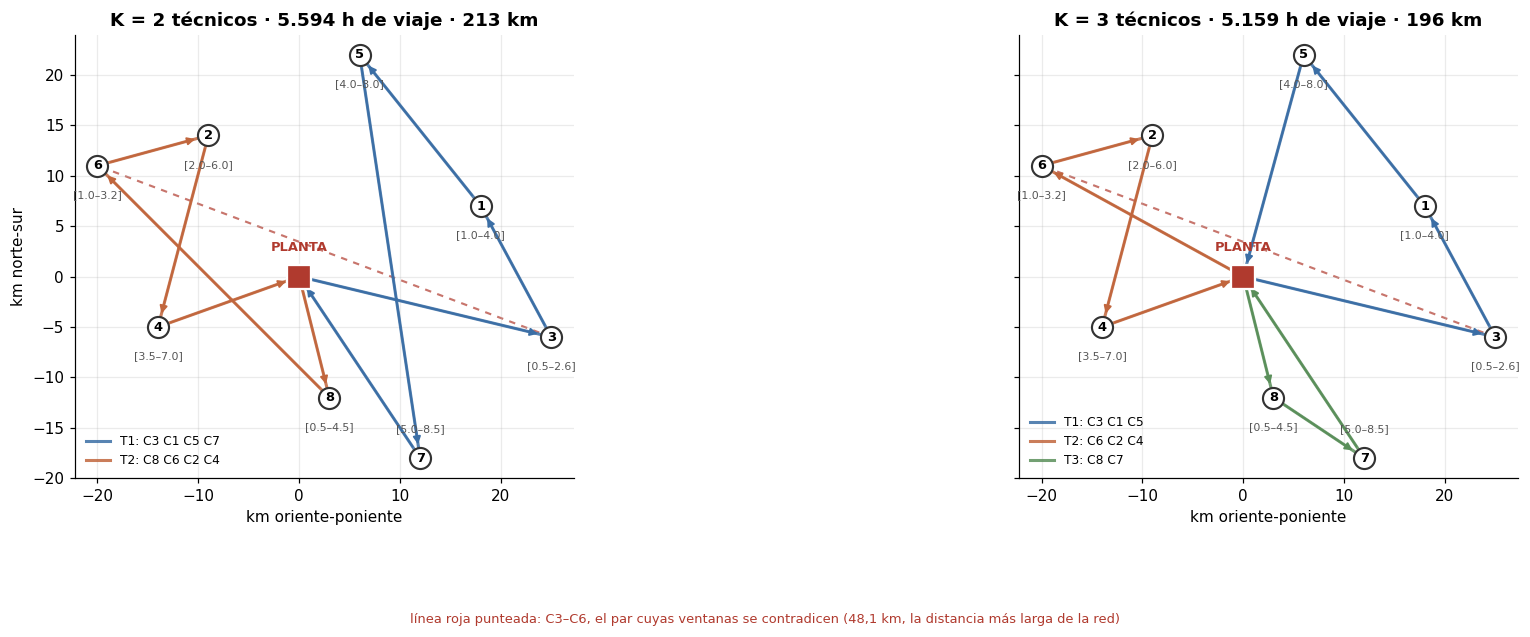

In [10]:
colores = ["#3b6ea5", "#c1663d", "#5a8f5a", "#8c6bb1"]
fig, axes = plt.subplots(1, 2, figsize=(14, 6.4), sharex=True, sharey=True)

for ax, K in zip(axes, (2, 3)):
    s = SOL[K]
    for n, ruta in enumerate(s["rutas"]):
        col = colores[n % len(colores)]
        xs = [xy[p][0] for p in ruta]
        ys = [xy[p][1] for p in ruta]
        ax.plot(xs, ys, "-", color=col, lw=2.0, alpha=0.85, zorder=2,
                label=f"T{n+1}: " + " ".join(ruta[1:-1]))
        for (i, j) in zip(ruta, ruta[1:]):
            ax.annotate("", xy=xy[j], xytext=xy[i], zorder=3,
                        arrowprops=dict(arrowstyle="-|>", color=col, lw=1.3,
                                        shrinkA=9, shrinkB=9))
    for c in CLIENTES:
        ax.scatter(*xy[c], s=190, color="white", edgecolor="#333333",
                   linewidth=1.4, zorder=4)
        ax.text(*xy[c], c[1:], ha="center", va="center", fontsize=8.5,
                fontweight="bold", zorder=5)
        # los clientes del extremo sur llevan la etiqueta arriba, para no
        # pisar el eje
        abajo = xy[c][1] > -14
        ax.text(xy[c][0], xy[c][1] + (-2.4 if abajo else 2.4),
                f"[{e[c]:.1f}–{l[c]:.1f}]", ha="center",
                va="top" if abajo else "bottom", fontsize=7.2,
                color="#555555", zorder=5)
    ax.scatter(*xy[DEPOSITO], marker="s", s=230, color="#b03a2e",
               edgecolor="white", linewidth=1.5, zorder=6)
    ax.text(xy[DEPOSITO][0], xy[DEPOSITO][1] + 2.2, "PLANTA", ha="center",
            va="bottom", fontsize=8.5, fontweight="bold", color="#b03a2e",
            zorder=6)
    ax.set_title(f"K = {K} técnicos · {s['objetivo']:.3f} h de viaje · "
                 f"{s['km']:.0f} km")
    ax.set_xlabel("km oriente-poniente")
    ax.legend(fontsize=8, loc="lower left")
    ax.grid(alpha=0.25)
    ax.set_aspect("equal", adjustable="box")

axes[0].set_ylabel("km norte-sur")
# Resaltar el par que hace infactible K = 1.
for ax in axes:
    ax.plot([xy["C3"][0], xy["C6"][0]], [xy["C3"][1], xy["C6"][1]],
            ls=(0, (3, 3)), color="#b03a2e", lw=1.4, alpha=0.7, zorder=1)
axes[1].text(0.5, 0.02,
             "línea roja punteada: C3–C6, el par cuyas ventanas se contradicen "
             "(48,1 km, la distancia más larga de la red)",
             transform=fig.transFigure, ha="center", va="bottom", fontsize=8.5,
             color="#b03a2e")

figura(fig, "mapa_rutas_vrptw")
plt.show()

## 8. Comprobación

Tres cosas distintas, y las tres hay que hacerlas:

1. Que el **valor** coincida con la referencia del curso.
2. Que el valor que informa el solver sea el del **calendario** que devuelve,
   recalculado sumando los `t_ij` de los arcos que efectivamente usa.
3. Que ese calendario sea **ejecutable**: cada cliente visitado una sola vez,
   cada ruta cerrada en el depósito, ninguna llegada después del cierre de su
   ventana, ningún retorno después de la jornada — **y permitiendo esperar**.

In [11]:
print("Comprobación:")
ok = []
ok.append(verificar(SOL[2]["objetivo"], 5.594, "K=2 · tiempo de viaje (h)", tol=1e-6))
ok.append(verificar(SOL[3]["objetivo"], 5.159, "K=3 · tiempo de viaje (h)", tol=1e-6))
ok.append(verificar(float(len(factibles)), 0.0,
                    "K=1 · órdenes factibles entre los 8!", tol=1e-9))
print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")

assert SOL[1]["estado"] == "INFEASIBLE", "con un técnico el modelo debe ser infactible"
assert len(factibles) == 0, \
    "la enumeración debe confirmar la infactibilidad del solver"
assert pares_imposibles == [("C3", "C6")], \
    "el par que se contradice debería ser exactamente C3-C6"


def verificar_solucion(K):
    s = SOL[K]
    assert s["estado"] == "OPTIMAL" and s["gap_%"] < 1e-4, f"K={K} no cerró"
    assert len(s["rutas"]) == K, f"K={K}: se esperaban {K} rutas"
    visitados, viaje = [], 0.0
    for ruta in s["rutas"]:
        assert ruta[0] == DEPOSITO and ruta[-1] == DEPOSITO, "ruta no cerrada"
        visitados += ruta[1:-1]
        df, factible_r, motivo = simular_ruta(ruta)
        assert factible_r, f"K={K}: ruta {ruta} no es ejecutable — {motivo}"
        # las esperas son legales, pero el servicio nunca antes de la llegada
        assert (df.inicio >= df.llegada - 1e-9).all(), \
            "el servicio no puede empezar antes de la llegada"
        for x in df.itertuples():
            if x.nodo == DEPOSITO:
                continue
            assert e[x.nodo] - 1e-9 <= x.inicio <= l[x.nodo] + 1e-9, \
                f"servicio en {x.nodo} fuera de su ventana"
        assert float(df.fin.iloc[-1]) <= JORNADA + 1e-9, "jornada excedida"
        viaje += sum(tv[(i, j)] for i, j in zip(ruta, ruta[1:]))
    assert sorted(visitados) == sorted(CLIENTES), \
        f"K={K}: cobertura incorrecta de clientes"
    assert abs(viaje - s["objetivo"]) < 1e-6, \
        (f"K={K}: el viaje recalculado sobre las rutas ({viaje:.4f}) no coincide "
         f"con el del solver ({s['objetivo']:.4f})")
    return viaje


for K in (2, 3):
    v = verificar_solucion(K)
    print(f"  K={K}: rutas ejecutables, cobertura completa, ventanas y jornada "
          f"respetadas, viaje recalculado {v:.4f} h")

# Hay espera de verdad: si no la hubiera, el punto del cuaderno seria abstracto.
assert espera_K2 > 1e-6, \
    "el plan de K=2 debería incluir espera; si no, el verificador estricto no fallaría"
print(f"\nHay {espera_K2:.3f} h de espera en el plan de K=2: un verificador que")
print("exigiera inicio == llegada habría rechazado el óptimo.")

# El resultado contraintuitivo, como asercion.
assert SOL[3]["objetivo"] < SOL[2]["objetivo"] - 1e-6, \
    "con ventanas, más vehículos puede reducir el viaje total"

detalle = []
for K in (2, 3):
    for n, ruta in enumerate(SOL[K]["rutas"], start=1):
        df, _ok, _m = simular_ruta(ruta)
        for x in df.itertuples():
            detalle.append({"K": K, "tecnico": f"T{n}", "nodo": x.nodo,
                            "viaje_h": x.viaje_h, "llegada": x.llegada,
                            "espera_h": x.espera_h, "inicio": x.inicio,
                            "fin": x.fin})
plan = pd.DataFrame(detalle)
tabla(plan, "vrptw_calendarios")
tabla(pd.DataFrame([{"K": K, "estado": SOL[K]["estado"],
                     "viaje_h": SOL[K]["objetivo"], "km": SOL[K].get("km"),
                     "rutas": " | ".join(" ".join(r) for r in SOL[K]["rutas"])}
                    for K in (1, 2, 3)]), "vrptw_resumen_flota")
resumen({"K1_estado": SOL[1]["estado"],
         "K1_ordenes_factibles_de_40320": len(factibles),
         "par_contradictorio": pares_imposibles,
         "holgura_C3_C6_h": round(
             max(tv[(DEPOSITO, "C3")], e["C3"]) + serv["C3"] + tv[("C3", "C6")]
             - l["C6"], 4),
         "K2_viaje_h": SOL[2]["objetivo"], "K2_km": SOL[2]["km"],
         "K3_viaje_h": SOL[3]["objetivo"], "K3_km": SOL[3]["km"],
         "K2_espera_h": espera_K2, "K3_espera_h": espera_K3,
         "rutas_K2": SOL[2]["rutas"], "rutas_K3": SOL[3]["rutas"]},
        "resumen_vrptw")
print("\nGuardado en resultados/")

Comprobación:
  [  OK  ] K=2 · tiempo de viaje (h): obtenido 5.5940 | referencia 5.5940 | dif. relativa 1.59e-16
  [  OK  ] K=3 · tiempo de viaje (h): obtenido 5.1590 | referencia 5.1590 | dif. relativa 0.00e+00
  [  OK  ] K=1 · órdenes factibles entre los 8!: obtenido 0.0000 | referencia 0.0000 | dif. relativa 0.00e+00

3/3 comprobaciones correctas
  K=2: rutas ejecutables, cobertura completa, ventanas y jornada respetadas, viaje recalculado 5.5940 h
  K=3: rutas ejecutables, cobertura completa, ventanas y jornada respetadas, viaje recalculado 5.1590 h

Hay 0.174 h de espera en el plan de K=2: un verificador que
exigiera inicio == llegada habría rechazado el óptimo.

Guardado en resultados/


---

## Para llevarse

1. **`INFEASIBLE` no es un diagnóstico.** El solver afirma que no hay
   solución y no dice por qué. El certificado —"C3 y C6 no caben en la misma
   ruta, y faltan dos minutos y medio"— se construye aparte: enumerando
   cuando se puede, y sobre todo **relajando** el problema a dos clientes,
   donde la respuesta se puede leer en voz alta. Un `INFEASIBLE` no abre
   ninguna conversación con el cliente; un certificado sí.
2. **En un VRPTW se puede esperar, y el verificador tiene que saberlo.** El
   servicio empieza en `max(llegada, e_j)`, no en `llegada`. Un verificador
   que exija la igualdad rechaza soluciones válidas y —lo peor— manda a buscar
   el error en el modelo, que está bien. El plan de dos técnicos de este
   cuaderno tiene espera obligatoria: es exactamente el caso que ese
   verificador equivocado habría rechazado.
3. **No se leen los instantes de las variables `a_i`: se simula la ruta.** El
   modelo solo acota esas variables y el objetivo no las castiga, así que
   pueden quedar en cualquier punto de su rango. El calendario real se
   reconstruye hacia adelante, y es lo único verificable.
4. **Con ventanas, más vehículos puede costar menos.** 5,594 h con dos
   técnicos y 5,159 h con tres. La monotonía que uno espera del VRP clásico
   depende de que no haya ventanas; con ventanas la flota mínima factible no
   tiene por qué ser la mejor, y hay que resolver las dos en vez de suponerlo.
5. **Las ventanas eliminan los subciclos gratis.** Encadenar la desigualdad de
   tiempo alrededor de un subciclo da `a_i ≥ a_i + (algo positivo)`. Por eso
   este modelo no lleva MTZ ni cortes de subciclo, y por eso el mismo modelo
   sin ventanas sí los necesitaría.

## Ejercicios

1. La ventana de C6 cierra a las 3,2 h y la llegada más temprana desde C3 es
   3,2425 h. Muévala a 3,25 h y vuelva a resolver con K = 1. ¿Se vuelve
   factible? Si no, repita el análisis de pares: ¿apareció otro par
   contradictorio que el primero estaba tapando?
2. Cambie el objetivo a `distancia` (los kilómetros) con K = 2. ¿Son las
   mismas rutas? Si difieren, explique cuál arco cambió y por qué: tiempo y
   distancia son proporcionales en estos datos salvo redondeo, así que
   cualquier diferencia merece explicación.
3. El objetivo minimiza tiempo de **viaje**, y la sección 5 mostró que eso no
   es lo mismo que minimizar la jornada del técnico, porque esperar es gratis.
   Escriba el modelo que minimiza la **hora de retorno más tardía** de la
   flota (agregue una variable `R` con `R ≥ a_i + serv_i + t_iD − (1−x_iD)·M`)
   y compare las rutas con las de la sección 4. ¿Cuál plan preferiría el
   técnico, y cuál el contador?